Published on July 01, 2025. By Prata, Marília (mpwolke)

In [10]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

#Two lines Required to Plot Plotly
import plotly.io as pio
pio.renderers.default = 'iframe'

import plotly.graph_objs as go
import plotly.offline as py
import plotly.express as px

#Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/pokemon-tcg-ai-battle-challenge-strategy/Card_ID List_JP.pdf
/kaggle/input/competitions/pokemon-tcg-ai-battle-challenge-strategy/Card_ID List_EN.pdf
/kaggle/input/competitions/pokemon-tcg-ai-battle-challenge-strategy/EN_Card_Data.csv
/kaggle/input/competitions/pokemon-tcg-ai-battle-challenge-strategy/JP_Card_Data.csv


## Overview

"This Strategy Category competition aims to explore methods for enhancing the performance of AI Training Agents with the Pokémon Trading Card Game (TCG). Participants are invited to share the ideas and approaches behind their AI Training Agents, focusing on systems where dynamic gameplay conditions are key factors for success."

Spoiler alert: Don't expect any AI Training Agent in this code 🙀

## What kind of Pokémon is that thing? 🤣😂

![](https://www.googleapis.com/download/storage/v1/b/kaggle-forum-message-attachments/o/inbox%2F3012786%2Fdd41a0abfb6e186e9710d6dba9effcac%2FWA_1781952563692.jpeg?generation=1782803524432214&alt=media)

## Competition Citation

@misc{pokemon-tcg-ai-battle-challenge-strategy,

    author = {The Pokémon Company, HEROZ, Matsuo Institute, Addison Howard, Bovard Doerschuk-Tiberi},
    
    title = {The Pokémon Company - PTCG AI Battle Challenge Strategy},
    year = {2026},
    
    howpublished = {\url{https://kaggle.com/competitions/pokemon-tcg-ai-battle-challenge-strategy}},
    note = {Kaggle}
}

In [11]:
df = pd.read_csv('/kaggle/input/competitions/pokemon-tcg-ai-battle-challenge-strategy/JP_Card_Data.csv')
df.tail(2)

,カード ID,カード名,エキスパンションマーク,コレクション番号,ポケモンの進化の段階/エネルギー・トレーナーズの種類,ルール,カテゴリ,進化前,HP,タイプ,弱点,抵抗力,にげる,ワザ名,コスト,ダメージ,効果の説明
2020,1266,夜の鉱山,M2a,188/193,スタジアム,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,おたがいの場の「テラスタル」のポケモン全員は、ワザを使うためのエネルギーが、それぞれ【無】エ...
2021,1267,ミアレシティ,M3,077/080,スタジアム,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,おたがいのプレイヤーは、自分の番ごとに1回、自分の山札から【たね】ポケモンを1枚選び、ベンチ...


In [12]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2022 entries, 0 to 2021
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   カード ID                      2022 non-null   int64  
 1   カード名                        2022 non-null   object 
 2   エキスパンションマーク                 2014 non-null   object 
 3   コレクション番号                    2022 non-null   object 
 4   ポケモンの進化の段階/エネルギー・トレーナーズの種類  2022 non-null   object 
 5   ルール                         353 non-null    object 
 6   カテゴリ                        392 non-null    object 
 7   進化前                         857 non-null    object 
 8   HP                          1815 non-null   float64
 9   タイプ                         1825 non-null   object 
 10  弱点                          1734 non-null   object 
 11  抵抗力                         376 non-null    object 
 12  にげる                         1748 non-null   float64
 13  ワザ名                         1811 

In [13]:
df1 = pd.read_csv('/kaggle/input/competitions/pokemon-tcg-ai-battle-challenge-strategy/EN_Card_Data.csv')
df1.tail(2)

,Card ID,Card Name,Expansion,Collection No.,Stage (Pokémon)/Type (Energy and Trainer),Rule,Category,Previous stage,HP,Type,Weakness,Resistance (Type),Retreat,Move Name,Cost,Damage,Effect Explanation
2020,1266,Nighttime Mine,ASC,197,Stadium,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Attacks used by each Tera Pokémon in play (bot...
2021,1267,Lumiose City,POR,77,Stadium,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Once during each player’s turn, that player ma..."


## Font for japanese characters

In [15]:
# Ken Toda https://www.kaggle.com/code/rentoda/starter-japanese-names-with-gender-extended/notebook

!wget -q https://github.com/googlefonts/noto-cjk/raw/main/Sans/OTF/Japanese/NotoSansCJKjp-Regular.otf -O /tmp/NotoSansCJK.otf
font_path = "/tmp/NotoSansCJK.otf"
from wordcloud import WordCloud

In [16]:
#Code by Jiazhen Xi https://www.kaggle.com/code/johnfarrell/chinese-news-wordcloud-eda/notebook

import matplotlib.font_manager as fm

prop = fm.FontProperties(fname=font_path)

In [ ]:
df['Card Name'].value_counts()

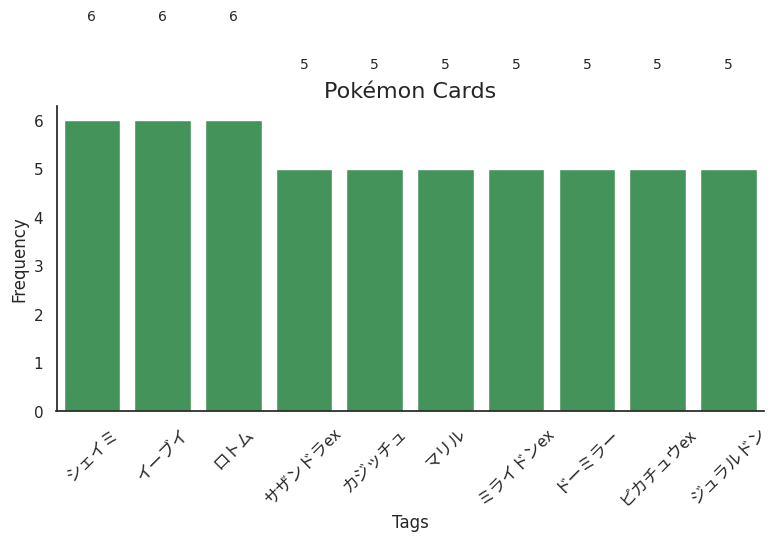

In [18]:
#By Pedro Andrade https://www.kaggle.com/code/pbizil/datahackers-managers-radiografia-dos-gestores

card_counts = df["カード名"].value_counts().head(10)#Try different values of head
sns.set(style="white")
plt.figure(figsize=(8, 6))
#x=type_counts.index, y=loc_counts.values
ax = sns.barplot(x=card_counts.index, y=card_counts.values, color=sns.color_palette("Greens", n_colors=5)[3])
plt.title("Pokémon Cards", fontsize=16)
plt.xlabel("Tags", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.xticks(rotation=45, fontsize=11, fontproperties=prop)
plt.yticks(fontsize=11)
sns.despine()

#+2 is good if chart is vertical. +20 worked for horizontal
for i, v in enumerate(card_counts.values):
    ax.text(i, v + 2, str(v), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

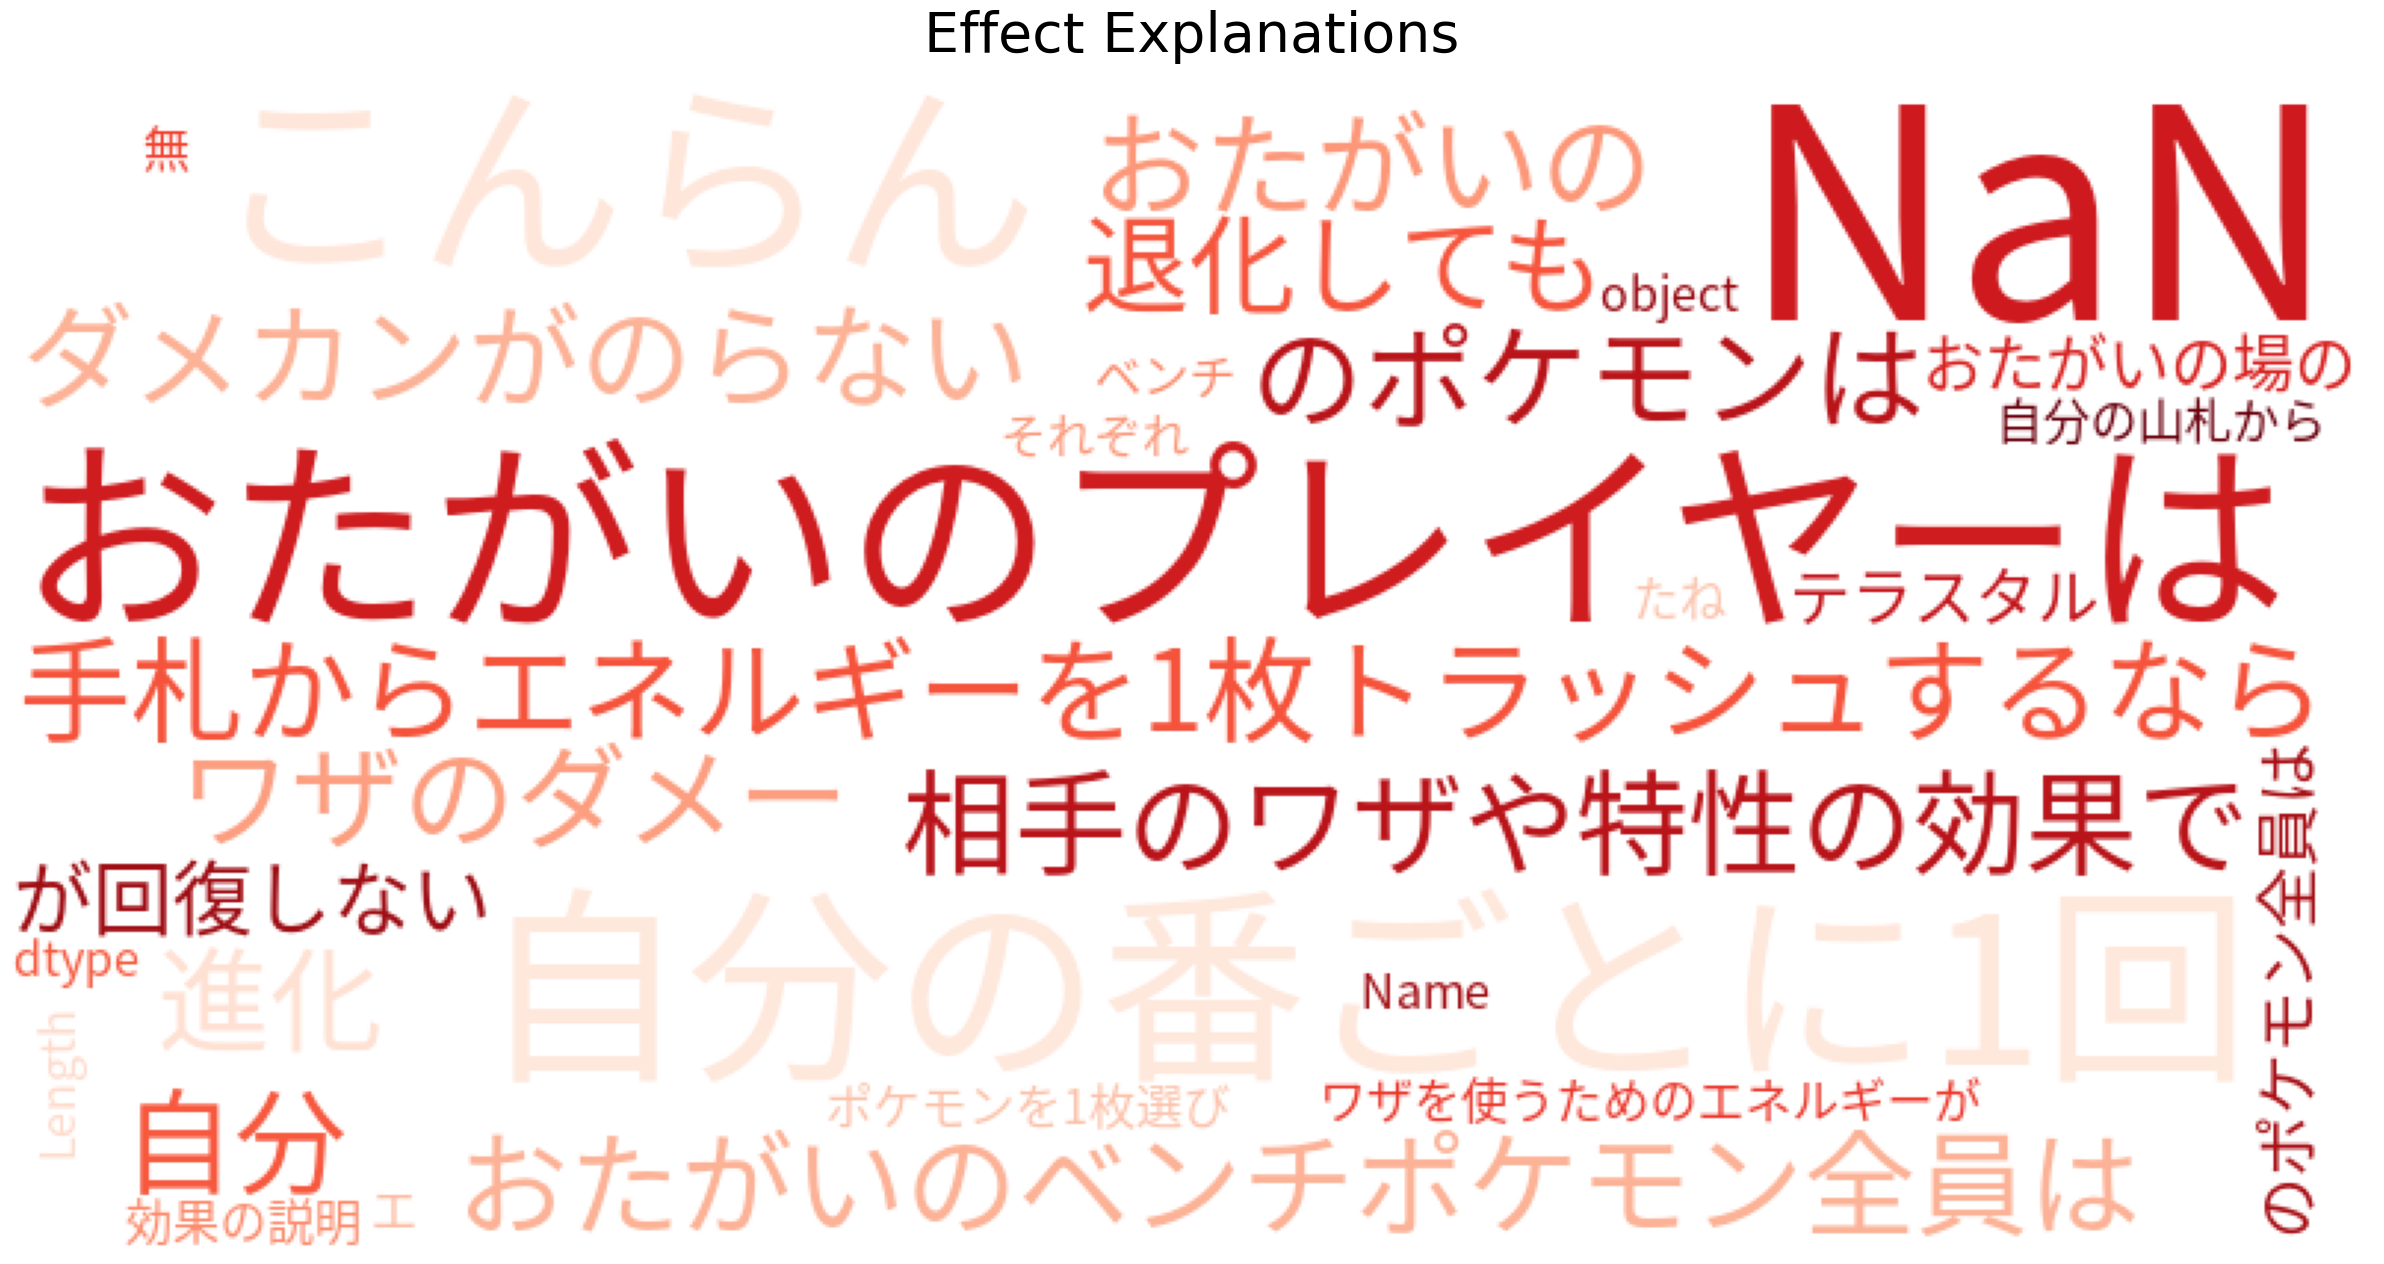

In [21]:
#By SRK https://www.kaggle.com/code/sudalairajkumar/simple-exploration-notebook-qiqc

from wordcloud import WordCloud, STOPWORDS

# Thanks : https://www.kaggle.com/aashita/word-clouds-of-various-shapes ##
def plot_wordcloud(text, mask=None, max_words=200, max_font_size=100, figure_size=(24.0,16.0), 
                   title = None, title_size=40, image_color=False):
    stopwords = set(STOPWORDS)
    more_stopwords = {'one', 'br', 'Po', 'th', 'sayi', 'fo', 'Unknown'}
    stopwords = stopwords.union(more_stopwords)

    wordcloud = WordCloud(background_color='white',
                    colormap='Reds',      
                    font_path=font_path,      
                    stopwords = stopwords,
                    max_words = max_words,
                    max_font_size = max_font_size, 
                    random_state = 42,
                    width=800, 
                    height=400,
                    mask = mask)
    wordcloud.generate(str(text))
    
    plt.figure(figsize=figure_size)
    if image_color:
        image_colors = ImageColorGenerator(mask);
        plt.imshow(wordcloud.recolor(color_func=image_colors), interpolation="bilinear");
        plt.title(title, fontdict={'size': title_size,  
                                  'verticalalignment': 'bottom'})
    else:
        plt.imshow(wordcloud);
        plt.title(title, fontdict={'size': title_size, 'color': 'black', 
                                  'verticalalignment': 'bottom'})
    plt.axis('off');
    plt.tight_layout()  
    
plot_wordcloud(df["効果の説明"], title="Effect Explanations")

### Fillna with 効果の説明 (Effect Explanations) 

In [22]:
# Fill up missing values in non-numerical columns
df['効果の説明'] = df['効果の説明'].fillna("効果の説明")

## fontproperties=prop

Add fontproperties=prop to plt.title to get the japanese characters.

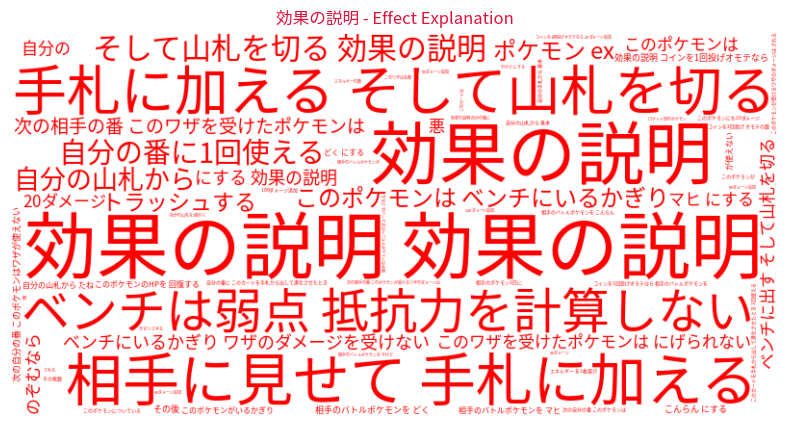

In [32]:
# 1. Convert the pandas series to raw text, which removes the 'dtype', 'Length', and 'Name'
text_data = ' '.join(df['効果の説明'].astype(str))

# 2. Generate the WordCloud
wordcloud = WordCloud(background_color='white',
                    color_func=lambda *args, **kwargs: "red", width=800, height=400, font_path=font_path).generate(text_data)

# 3. Display the WordCloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off') 
plt.title('効果の説明 - Effect Explanation',fontproperties=prop, color='#DC143C')
plt.show()

In [35]:
from pathlib import Path
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
import time

from pathlib import Path
from wordcloud import WordCloud
from collections import Counter

In [63]:
#https://seaborn.pydata.org/generated/seaborn.color_palette.html
#Harish Vutukuri https://www.kaggle.com/code/harishvutukuri/chaai-quick-eda/notebook

train_corpus = df['効果の説明']
#test_corpus = test_df['context']

def get_top_n_unigram(corpus, n=None):
    vec = CountVectorizer().fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq =sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:n]

def get_top_n_bigram(corpus, n=None):
    vec = CountVectorizer(ngram_range=(2, 2)).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq =sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:n]

def get_top_n_trigram(corpus, n=None):
    vec = CountVectorizer(ngram_range=(3, 3)).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq =sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:n]

def plot_top_n(corpus: list, title: str = None):
    df = pd.DataFrame(corpus, columns=['word','freq'])
    plt.figure(figsize=(16, 8))
    ax = sns.barplot(x='freq', y='word', data=df, facecolor=(0, 0, 0, 0), linewidth=2, edgecolor=sns.color_palette("rainbow", 20))
    ax.bar_label(ax.containers[0], padding=5) #To change colors https://seaborn.pydata.org/generated/seaborn.color_palette.html
       
    plt.title(title)
    plt.xlabel("Frequency")
    
    plt.yticks(fontproperties=prop) ## Worked to plot japanese characters on y-axis 
    plt.yticks()
    plt.show()

## Top unigrams

I think the top is the Nan that I replaced by the column name : (

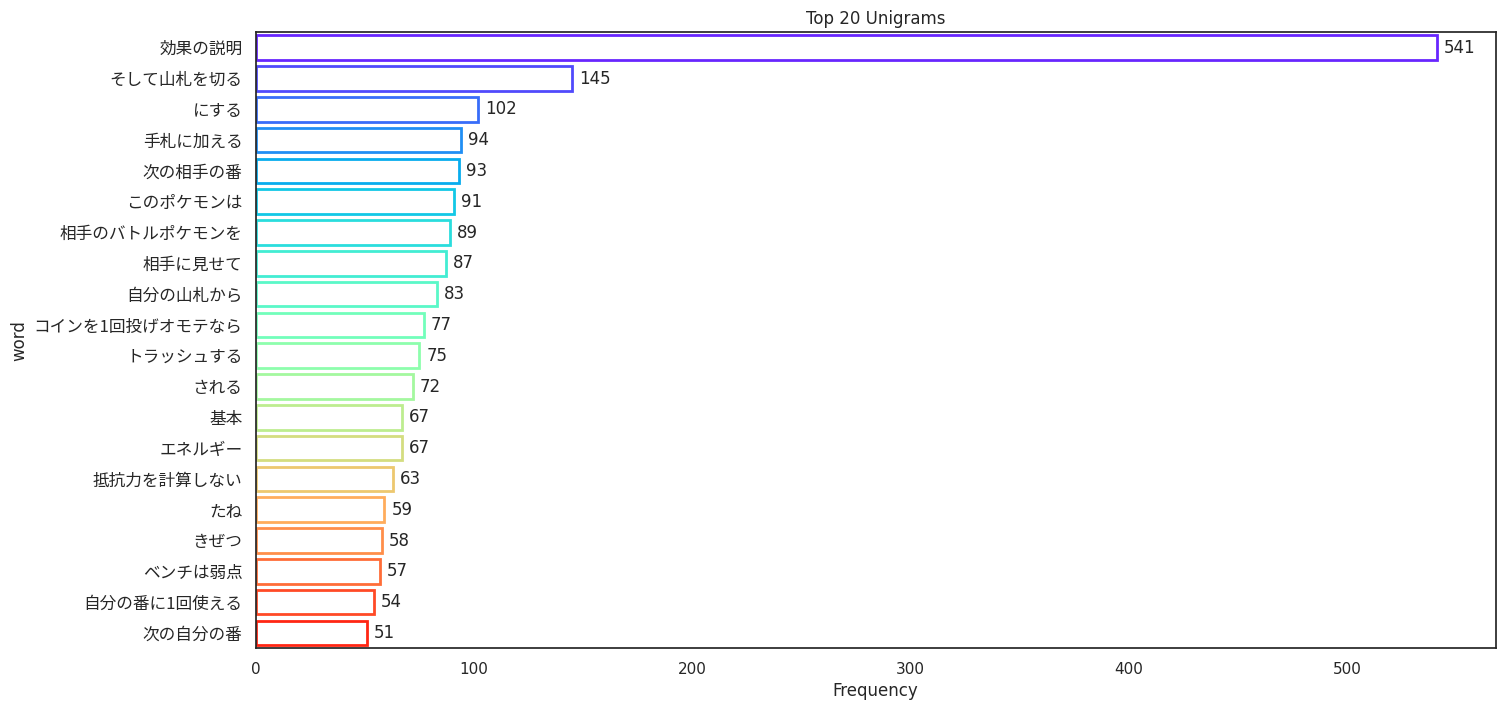

In [64]:
plot_top_n(get_top_n_unigram(train_corpus, 20), title="Top 20 Unigrams")

## Bigrams

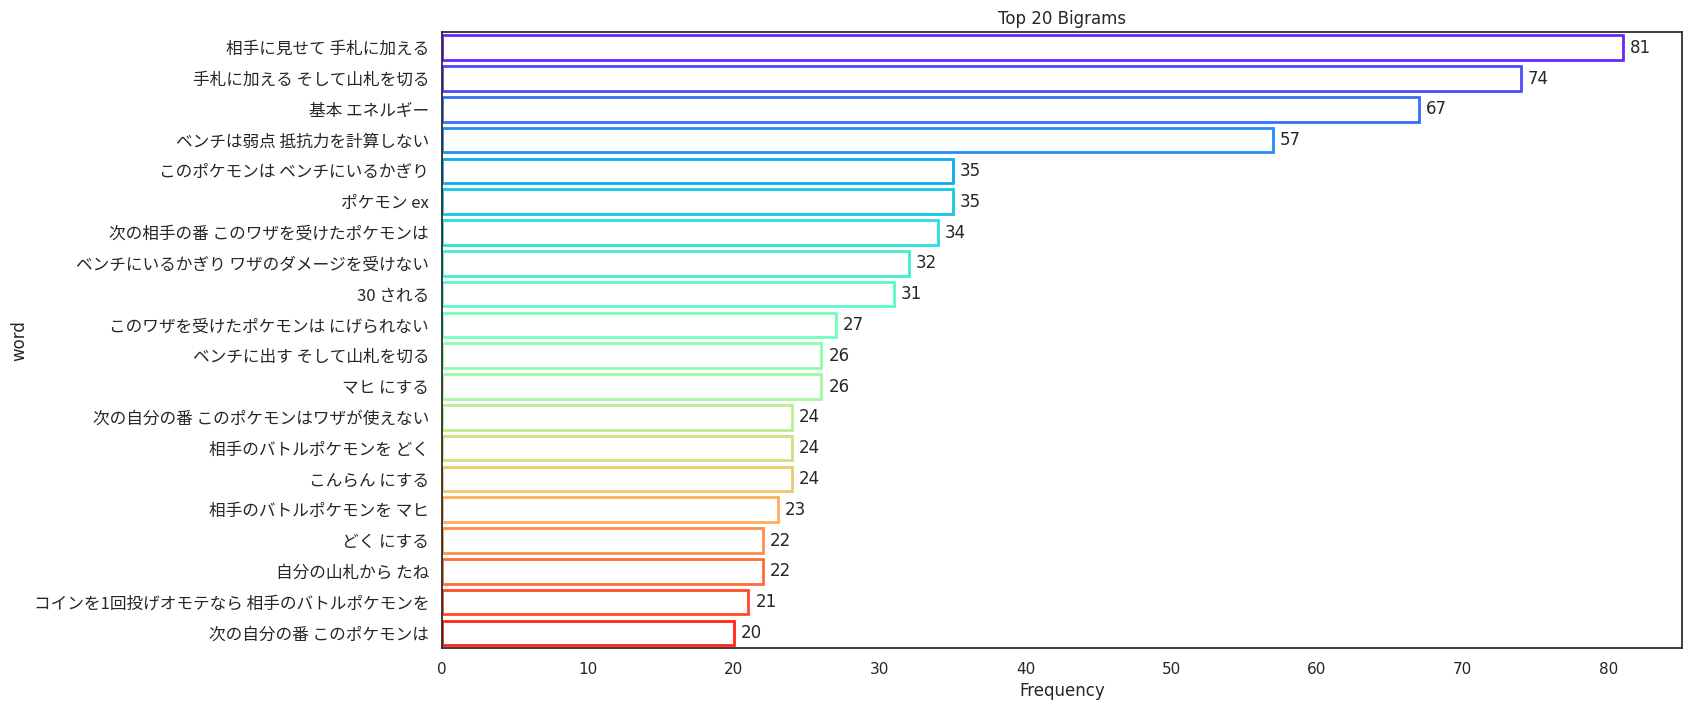

In [65]:
plot_top_n(get_top_n_bigram(train_corpus, 20), title="Top 20 Bigrams")

## Trigrams

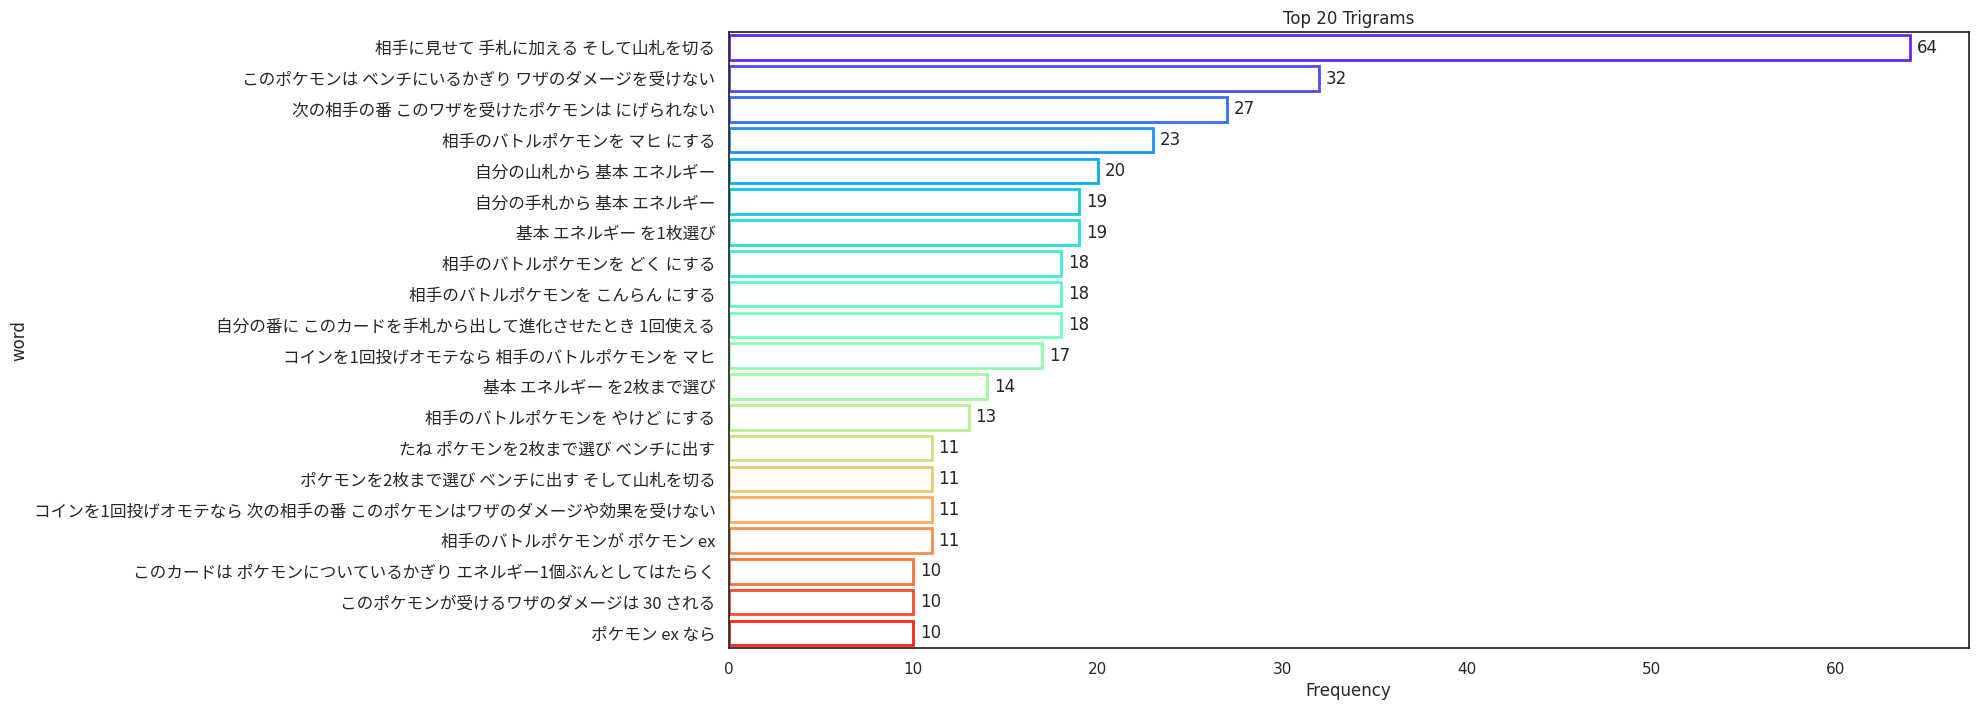

In [66]:
plot_top_n(get_top_n_trigram(train_corpus, 20), title="Top 20 Trigrams")

## Draft Session: 2h:36m and No Pokémon AI Agent at All 🫤

#Acknowledgements:

Ken Toda https://www.kaggle.com/code/rentoda/starter-japanese-names-with-gender-extended/notebook

Pedro Andrade https://www.kaggle.com/code/pbizil/datahackers-managers-radiografia-dos-gestores

SRK https://www.kaggle.com/code/sudalairajkumar/simple-exploration-notebook-qiqc

Harish Vutukuri https://www.kaggle.com/code/harishvutukuri/chaai-quick-eda/notebook

mpwolke https://www.kaggle.com/code/mpwolke/kullm-korean-translation/notebook

mpwolke https://www.kaggle.com/code/mpwolke/chinese-word2vec-embedding/notebook

这 notebook 是个纯 EDA（探索性数据分析），作者自己也调侃 **"Don't expect any AI Training Agent in this code 🙀"**——里面只有日文/英文卡牌数据的对比可视化和词云，没有可运行的对战 Agent。

对你今天的 **5 发提交**，核心矛盾是：**Kaggle 限制 5 发/天，容错极低，第一性目标不是"赢"，而是"先稳定拿到有效分数，再迭代"。**

## 今天 5 发提交策略（极简版）

| 发数 | 目标 | 动作 |
|------|------|------|
| **第 1 发** | **验证链路** | 用胡地卡组（你之前提到的稳定构筑）+ 最保守规则 Agent（能出牌就出，优先Attach能量，优先进化）。**唯一目的是确认 API 调用→对局→提交→出分整条链路通**。不要追求策略复杂，追求不报错、不超时。 |
| **第 2 发** | ** baseline 调优** | 基于 EDA 数据（比如你刚发的 notebook 里卡牌效果文本），微调卡组张数（比如能量/物品/支援卡比例），做 A/B 测试。 |
| **第 3 发** | **加入状态机** | 在规则 Agent 里加简单状态判断：己方/对方奖品卡差、HP 阈值、是否优先拿奖。 |
| **第 4 发** | **针对环境** | 如果前三发分数稳定，这发测试"激进策略"（如优先铺场、前期抢奖）；如果分数波动大，改为更保守的控场策略。 |
| **第 5 发** | **保留弹** | 如果前面有某发分数特别高，这发做该版本的微小优化（±2-3 张卡）；如果前面都崩了，这发退回最稳版本重新提交。 |

## 关键提醒

1. **胡地卡组的优势是"稳定"**，在环境千奇百怪时，稳定 Agent 的方差小，反而容易吃分。不要第一发就试骚套路。
2. **那个 notebook 的价值**：可以用来快速查卡牌日文效果（`JP_Card_Data.csv`），确认你 vibecode 时 Agent 对卡牌的理解没有偏差，但别指望直接跑它提交。
3. **今天第一发之前**：务必本地/Notebook 里先跑通一局完整对局日志，确认没有 `KeyError` 或 API 超时。

你现在的 Agent 代码骨架搭好了吗？如果还没跑通第一局，先别急着交，把第一发当"冒烟测试"（smoke test）用。需要我帮你写一个最简胡地卡组规则 Agent 的伪代码框架吗？